# Order Book Imbalance (OBI) study

Reads `snapshots.csv` from the C++ engine. Computes top-of-book OBI, forward mid returns, and **test-set** correlations only (time-based 70/30 split).

**Not a trading strategy** — no costs, queue position, or capacity. Interpret cautiously.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path("..").resolve()
SNAP_PATH = ROOT / "data" / "snapshots_real.csv"  # real LOBSTER; or snapshots_replay.csv for synthetic
TRAIN_FRAC = 0.70
HORIZONS_NS = {
    "100ms": 100_000_000,
    "1s": 1_000_000_000,
    "5s": 5_000_000_000,
}
PRIMARY = "1s"

In [14]:
df = pd.read_csv(SNAP_PATH)
df = df.dropna(subset=["best_bid", "best_ask", "bid_sz_1", "ask_sz_1"])
df = df[(df["bid_sz_1"] > 0) & (df["ask_sz_1"] > 0)].copy()

df["mid"] = 0.5 * (df["best_bid"] + df["best_ask"])
denom = df["bid_sz_1"] + df["ask_sz_1"]
df["obi"] = (df["bid_sz_1"] - df["ask_sz_1"]) / denom

print(f"rows={len(df):,}  time span ns={df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]:,}")
df.head()

rows=4,003  time span ns=23,395,909,706,135


,timestamp,best_bid,best_ask,bid_px_1,bid_sz_1,ask_px_1,ask_sz_1,bid_px_2,bid_sz_2,ask_px_2,...,bid_px_4,bid_sz_4,ask_px_4,ask_sz_4,bid_px_5,bid_sz_5,ask_px_5,ask_sz_5,mid,obi
0,34200888641822,58571,58587,58571,18,58587,100,58570,44,58593,...,58565,5,58598,400,58564,20,58599,100,58579.0,-0.694915
1,34201840808542,58547,58577,58547,18,58577,18,58546,5,58578,...,58542,100,58587,100,58540,50,58589,300,58562.0,0.000000
2,34203954770435,58545,58571,58545,18,58571,100,58544,167,58580,...,58538,22,58587,100,58537,100,58589,100,58558.0,-0.694915
3,34209829435704,58544,58566,58544,66,58566,171,58540,50,58567,...,58536,5,58580,200,58530,230,58581,100,58555.0,-0.443038
4,34215204460371,58536,58542,58536,100,58542,320,58530,230,58554,...,58510,5,58568,2,58505,1,58580,200,58539.0,-0.523810


In [15]:
def forward_mid_return(timestamps: np.ndarray, mids: np.ndarray, horizon_ns: int) -> np.ndarray:
    """For each t, find first mid at timestamp >= t + horizon (no look-ahead on features)."""
    n = len(timestamps)
    out = np.full(n, np.nan)
    j = 0
    for i in range(n):
        target = timestamps[i] + horizon_ns
        if j < i:
            j = i
        while j < n and timestamps[j] < target:
            j += 1
        if j < n and mids[i] != 0:
            out[i] = (mids[j] - mids[i]) / mids[i]
    return out

ts = df["timestamp"].to_numpy()
mid = df["mid"].to_numpy(dtype=float)
for name, h in HORIZONS_NS.items():
    df[f"ret_{name}"] = forward_mid_return(ts, mid, h)

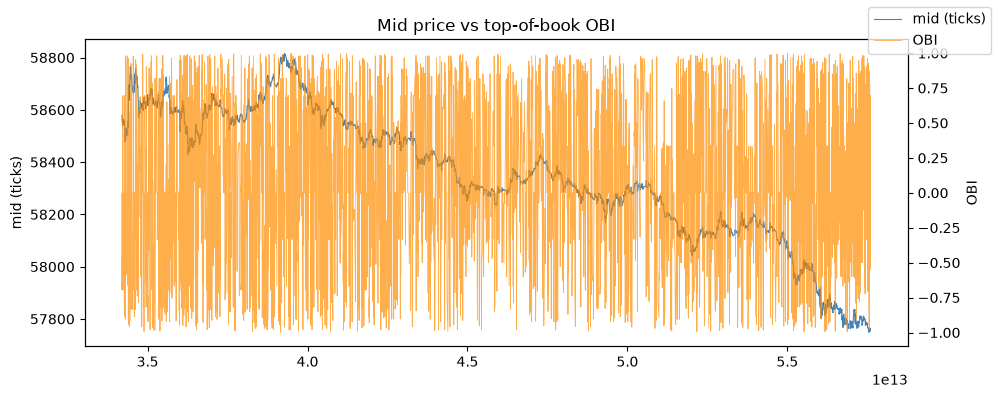

In [16]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(df["timestamp"], df["mid"], color="steelblue", lw=0.8, label="mid (ticks)")
ax1.set_ylabel("mid (ticks)")
ax2 = ax1.twinx()
ax2.plot(df["timestamp"], df["obi"], color="darkorange", lw=0.6, alpha=0.7, label="OBI")
ax2.set_ylabel("OBI")
ax1.set_title("Mid price vs top-of-book OBI")
fig.legend(loc="upper right")
plt.tight_layout()
plt.show()

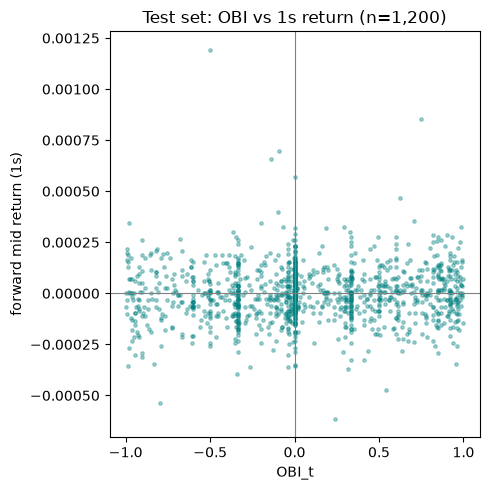

In [17]:
ret_col = f"ret_{PRIMARY}"
split = int(len(df) * TRAIN_FRAC)
train = df.iloc[:split]
test = df.iloc[split:].dropna(subset=[ret_col])

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(test["obi"], test[ret_col], s=6, alpha=0.35, c="teal")
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel("OBI_t")
ax.set_ylabel(f"forward mid return ({PRIMARY})")
ax.set_title(f"Test set: OBI vs {PRIMARY} return (n={len(test):,})")
plt.tight_layout()
plt.show()

In [18]:
def report_corr(name: str, x: np.ndarray, y: np.ndarray) -> None:
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 3:
        print(f"{name}: too few points")
        return
    pearson = stats.pearsonr(x, y)
    spearman = stats.spearmanr(x, y)
    print(
        f"{name}: n={len(x):,}  "
        f"Pearson r={pearson.statistic:.4f} (p={pearson.pvalue:.2e})  "
        f"Spearman ρ={spearman.statistic:.4f} (p={spearman.pvalue:.2e})"
    )

print("=== TEST SET ONLY (last 30% by time) ===")
for name in HORIZONS_NS:
    col = f"ret_{name}"
    sub = test.dropna(subset=[col]) if name == PRIMARY else df.iloc[split:].dropna(subset=[col])
    report_corr(name, sub["obi"].to_numpy(), sub[col].to_numpy())

print("\nTrain-set correlations are for diagnostics only — do not quote as results.")
for name in HORIZONS_NS:
    col = f"ret_{name}"
    sub = train.dropna(subset=[col])
    report_corr(f"train/{name}", sub["obi"].to_numpy(), sub[col].to_numpy())

print(
    "\nHow to read this:\n"
    "  Pearson r near 0  → OBI and future mid move look unrelated.\n"
    "  Pearson r > 0     → when bid size dominates (OBI>0), mid more often rises next.\n"
    "  NaN / too few     → horizon longer than the data, or mid never moved.\n"
    "  This sample is synthetic with a planted OBI→drift link — for learning, not alpha."
)

=== TEST SET ONLY (last 30% by time) ===
100ms: n=1,200  Pearson r=0.0620 (p=3.17e-02)  Spearman ρ=0.0690 (p=1.68e-02)
1s: n=1,200  Pearson r=0.0538 (p=6.23e-02)  Spearman ρ=0.0650 (p=2.43e-02)
5s: n=1,199  Pearson r=0.0081 (p=7.80e-01)  Spearman ρ=0.0318 (p=2.71e-01)

Train-set correlations are for diagnostics only — do not quote as results.
train/100ms: n=2,802  Pearson r=0.0044 (p=8.16e-01)  Spearman ρ=0.0134 (p=4.78e-01)
train/1s: n=2,802  Pearson r=0.0049 (p=7.94e-01)  Spearman ρ=0.0120 (p=5.27e-01)
train/5s: n=2,802  Pearson r=0.0062 (p=7.44e-01)  Spearman ρ=0.0168 (p=3.73e-01)

How to read this:
  Pearson r near 0  → OBI and future mid move look unrelated.
  Pearson r > 0     → when bid size dominates (OBI>0), mid more often rises next.
  NaN / too few     → horizon longer than the data, or mid never moved.
  This sample is synthetic with a planted OBI→drift link — for learning, not alpha.
